In [1]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()

In [2]:
# Start with a bigram language model, a very simple language model
# Looks only at two characters in a row: given previous character, what character is likely to come next?

In [3]:
# Look at pairs of consecutive characters in the words and count the frequency of each pair

b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>'] # special start token + word + special end token
    for ch1, ch2 in zip(chs, chs[1:]): # get pairs of consecutive characters
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1 # if bigram is not in the dictionary, value = 1
        
b_sorted = sorted(b.items(), key = lambda kv: -kv[1])

In [4]:
# Correlation Matrix for bigrams

N = torch.zeros((27, 27), dtype = torch.int32)
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)} # lookup table to map characters to integers
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()} # inverse of stoi

In [5]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

(-0.5, 26.5, 26.5, -0.5)

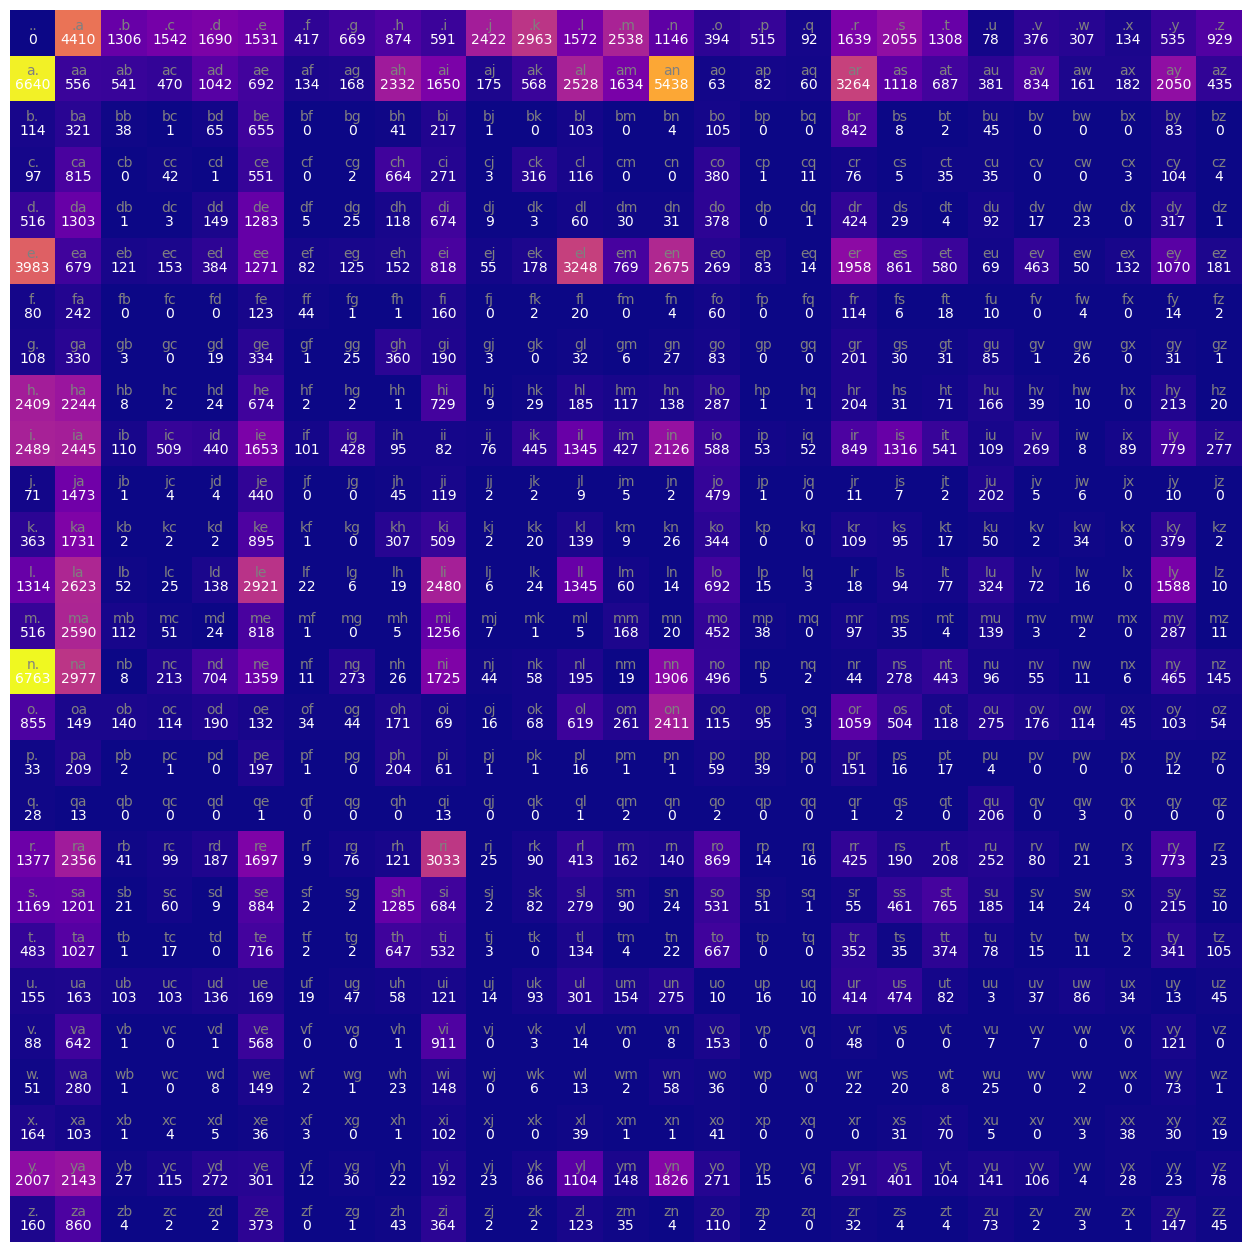

In [6]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='plasma')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='white')
plt.axis('off')

In [7]:
# Sampling

p = N[0].float()
p /= p.sum() # normalize to get a probability distribution
p # Sample from this distribution

g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]
# why do we use multinomial distribution to sample from the distribution p?
# Binomial disrbution is nCr p^r * (1-p)^(n-r)
# Multinomial is generalization of this for multiple possible outcomes
# But our p itself is a pmf
# Is using multinomial distribution just a method for sampling? 
# So somehow setting out pmf p equal to the parameter p in the multinomial distribution does this
# Would we get a similar behavior if we did another method for sampling like inverse transform sampling?
# Yes

# So we sample a first character
# Then we sample a second character based on the first character ix (index), etc

'c'

In [ ]:
P = (N+1).float() # N+1 rather than N for "Model Smoothing": So no pair is infinitely unlikely - messes up loss function (nll)
P /= P.sum(1, keepdim=True) # Consider PyTorch Broadcasting Semantics
# The larger number you add to N in the first line (N+1) vs (N+10000), the more smooth
# P = P / P.sum(1) causes a bug due to broadcasting rules. Video 2 @ 47:19.
# This actually causes the columns to be normalized (kinda just since sum of column = sum of row here, which I think is luck) rather than the rows
# But basically the keepdim=False makes us divide each column by the corresponding row sum, which is wrong

# Is P a Stochastic / Markov Matrix?

# P is the matrix of the parameters of the model. We trained the model just by counting

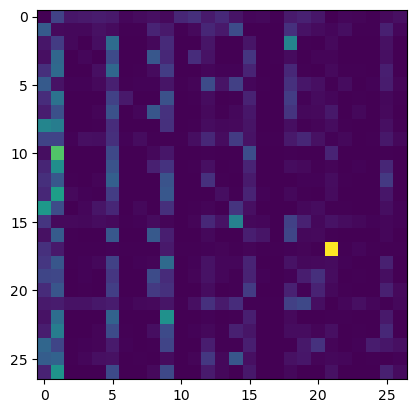

In [9]:
plt.imshow(P)

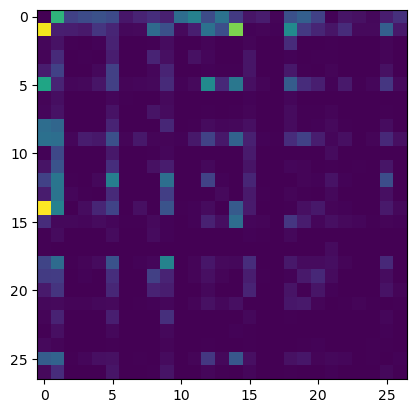

In [10]:
plt.imshow(N)
# why dont these heat maps look the same?

In [11]:
# Sampling Loop
# Here we sample from the model
g = torch.Generator().manual_seed(2147483647)

for _ in range(5):
    out = []
    ix = 0 # start with the start token
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix == 0: # this we have drawn the end token
            break
        out.append(itos[ix])
    print(''.join(out))

cexze
momasurailezitynn
konimittain
llayn
ka


In [12]:
# Loss Function
# We want to evaluate how well the model did
# My guess is we are going to count the character pairs in the data (words) generated by our model (so basically train a new model based on this generated data)
# and compare the character pair counts from our generated data to those from the training data

# the thing thats better about the approach below than this is that this would require generating a ton of data. expensive.
# in the real approach (below), we are evaluating the weights of the model with the training data
# also I wonder if this approach would lead to overfitting...idk maybe they both could risk that

In [13]:
# Note at vid 2 @ 52:20 that confuses me
# if everything was equally likely wouldnt it be 1/27^2 not 1/27?
# Why does seeing a prob above 1/27 ~= 4% mean the model learned something?
# said that seeing this ^ means the model assigned a high probability to whatever is in the training set, which is good.
# that makes sense but seems more nuanced than that...

n = 0
log_likelihood = 0.0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2] # so we know that (ch1, ch2) is a real pair - so the probability of seeing that pair that the model learned should be high often?
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
nll = -log_likelihood
print(f'{nll=}')
print(f'average (normalized) negative log likelihood = {nll/n}')

# Maximum Likelihood Estimation: use the likelihood as a single number evaluting the entire model
# the likelihood is the product of all prob in the loop above
# this is telling us the probability of observing the entire training date set, given the model parameters
# this makes sense as a score
# for convenience, we use the log likelihood
# is addition cheaper? or do we just not want a number between 0 and 1 only?
# log1 = 0 so max log likelihood is 0
# want loss function (minimizing loss is general goal in ML) to be such that small loss = good model
# thus, negative log likelihood is our loss function (or average nll)
# the minimum possible value of nll is 0
# average makes sense because with just the nll, you're getting punished just for evaluating the model on more data

# notice: average nll = -(1/n)*sum_ij log(p_ij) is the Empirical Shannon Entropy
# maximizing the likelihood is equivalence to minimizing the shannon entropy
# im not sure I get this - the entropy is a function of the prob distribution, which is determined by model parameters, which are determined by the training data in a deterministic way
# its not like Im minimizing the mutual information between the training data and the model by updating the model parameters
# so why is the entropy a measure of the model's performance rather than just something inherent to the training data?
# i thought it was going to be something like ensuring that the training data is a typical set of the prob distribution that the model learned
# or the mutual information between the training data distribution and the model distribution: 
# basically we dont want to be surpised by drawing the training data as a sample from the model distribution
# so: given the model parameters, we do not "learn" much shannon information by observing the training data
# is that what's happening?

# Goal is the maximize the likelihood of the training data with respect to the model parameters (this is statistical modeling)
# this is equivalent to maximizing the log likelihood (because log is monotonic)
# this is equivalent to minimizing the average negative log likelihood

nll=tensor(559951.5625)
average (normalized) negative log likelihood = 2.4543561935424805


In [14]:
# We now build a Neural Network (still a bigram character level language model)
# I think the benefit of this is that we can train the weights iteratively
# Also neural nets are jsut more general structures so this is a good way to start

In [15]:
# create training set of bigrams (x, y): x is input, y is target

import torch.nn.functional as F
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

# adviced to use torch.tensor() rather than torch.Tensor()

# xs and ys tensors contain integer indexes of characters
# dont want to feed integers into neural network
# One Hot Encoding: Common way of encoding integers (or categorical data?)
# I believe this is: int i --> e_i, the i-th standard basis vector in R^n, where n = 27 here

xenc = F.one_hot(xs, num_classes=27).float()
yenc = F.one_hot(ys, num_classes=27).float()

In [16]:
# Construct First Neuron

#W = torch.randn((27, 1)) # column vector for a: dim 27 x 1
#xenc @ W # this evaluates the training data on this neuron's 27 weights

# there are 27 characters: these are 27 input features I believe
# A single neuron thus needs 27 weights

# =======================================================================
#  Construct First Layer (27 Neurons, each with 27 weights)

W = torch.randn((27, 27), generator=g, requires_grad=True) # this creates 27 neurons (this is a layer)
# so this architecture we chose must just say we have an individual nueron for every feature of the data

# We are making an extremely simple neuron network layer
# No bias, linear activation (basically no activation), and only one layer (so a linear layer)
# Also I believe that right matrix mult xenc @ W is a way of having a fully connected (dense) layer
# that is, the input layer and the next layer together would form a complete bipartite graph K_n,m

In [17]:
# Forward Pass:

# xenc is the training data inputs
# W is the nn weights
# This nn outputs 27 numbers, which together represent the probability distrbution of the next character
# A prob distribution needs to be normalized and each prob must be 0 <= p <= 1: a nn won't automatically do this
# thus we interpret the output of the nn as unnormalized log counts
# because 0 < e^x < 1 for x < 0 and e^x > 1 for x > 0
# how is this different than having an activation of exp()?

xenc @ W
(xenc @ W)[3, 13] # this is the firing rate of the 13th neuron looking at the 3rd input
logits = xenc @ W # log-counts
counts = logits.exp() # this is equivalent to the N in our previous model: each row is the counts of the next char
prob = counts / counts.sum(1, keepdim=True)
# The two lines above that take logits --> exp(logits_i) / sum_j exp(logits_j) is called the softmax activation function
# Softmax Function is a common layer
# Softmax takes the output of a layer (any pos and neg numbers) and turns it into a probability distribution


prob[0] # so this is the pmf of the next char for the first training character (start token)


# okay I need to understand why logits is something that looks / behaves like counts
# xenc is the training data, W is the model weights
# consider a single row of xenc: this represents one character
# taking the dot product of this row with a single column of W is dotting a character with the probability of next characters, given what???
# if its like each neuron is for a specific character (feature), then dotting one char with the probs of the next char given that neurons char
# would only return a large number (dot product) if those that char is that neurons char
# because the vector W[: j] has components that are probs for each next char, GIVEN char j is the current
# I guess these vectors will only line up if we have char j (or some char with similar statistics)


# So in summary, this nn has a linear layer and a softmax activation layer.

# In micrograd we were doing regression and thus used mean-squared error loss
# Here we are doing classification and thus using average negative log likelihood loss

tensor([0.0198, 0.0423, 0.1426, 0.0115, 0.0102, 0.0346, 0.0297, 0.0273, 0.0042,
        0.0581, 0.0098, 0.0231, 0.0227, 0.0086, 0.0025, 0.0297, 0.0408, 0.0371,
        0.0501, 0.0076, 0.0805, 0.0089, 0.1984, 0.0448, 0.0038, 0.0290, 0.0223],
       grad_fn=<SelectBackward0>)

In [18]:
# Now back propagation through the nn and perform gradient descent to train the nn
# confused at vid 2 1:33:02 why output probs of the network is prob[i] rather than prob[x]
# in the loop we look at the i-th bigram, which is (xs[i], ys[i])
# this bigram is the char pair (itos[x], itos[y]) with indices (x, y)
# so don't we want P(y | x) = prob[x, y]?
# i represents a training example, not a char index

# I dont think it was a typo I think it really is supposed to be prob[i, y]
# well this makes sense I guess because if we were simply looking for probabilities for a given first character, then the mode may become too simple
# it could be deterministic because it only predicts a single character to follow every character
# by looking at every example insetad of every character, we are saying: how likely is this bigram (character pairing)?
# doing this for all examples will encapsulate all the possibiities

num_examples = xenc.shape[0]
nlls = torch.zeros(num_examples)

for i in range(num_examples):
    x = xs[i]
    y = ys[i]
    p = prob[i, y] # ? 
    logp = torch.log(p)
    nll = -logp
    nlls[i] = nll
    
# Loss for the entire model:
avg_nll = nlls.mean().item()
avg_nll


3.910064697265625

In [19]:
# Loss
# We are interested in the probabilities assigned to our training data outputs
print(prob[torch.arange(num_examples), ys])
loss = -prob[torch.arange(num_examples), ys].log().mean() # average nll
loss

tensor([0.0346, 0.0363, 0.0126,  ..., 0.0255, 0.0127, 0.0278],
       grad_fn=<IndexBackward0>)


tensor(3.9101, grad_fn=<NegBackward0>)

In [20]:
# Backward Pass
W.grad = None # set grad to zero
loss.backward() # some one time use error here if I manually loop over cells

In [21]:
# Update Weights
# We don't need to loop over all parameters like in micrograd because we have a single parameter tensor
W.data += -0.1 * W.grad
xenc.dtype

torch.float32

In [77]:
# OKAY EVERYTHING REWRITTEN CLEANLY

# create train dataset
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement() # number of examples

# initialize the neural network
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [78]:
# Regularization
# In the nn approach, we can do smoothing by trying to insentivize W to be near 0 matrix
# Because then logits becomes all 1
# and then we get uniform probs
# So we add a regularization term onto the end of the loss:
# (W**2).mean() because squaring W turns all values positive
# and now we are punished W for having values away from 0
# he said think of this like adding a small spring force or gravity force towards zero
# so the strength of the regularization term (0.01) is like the number you add to couunts in cell 8: P = (N+1).float()

In [79]:
# Gradient Descent

num_itr = 100
for k in range(num_itr):
    
    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float() # so the type of this just says torch.float32. But its a tensor of floats right?
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True) # this and the line above are the softmax layer
    # loss = -probs[torch.arange(num), ys].log().mean() # loss without regularization
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
    
    if k == 0 or k == num_itr - 1:
        print(f'loss at step {k} = {loss.item()}')
    
    # backward pass
    W.grad = None
    loss.backward()
    
    # update weights
    W.data += -50.0 * W.grad

loss at step 0 = 3.76861834526062
loss at step 99 = 2.4901304244995117


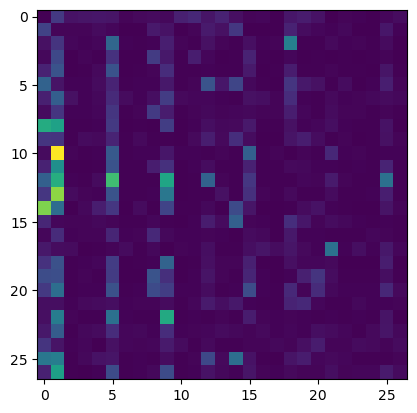

In [81]:
plt.imshow(W.exp().detach()) # this should look like the counts matrix N

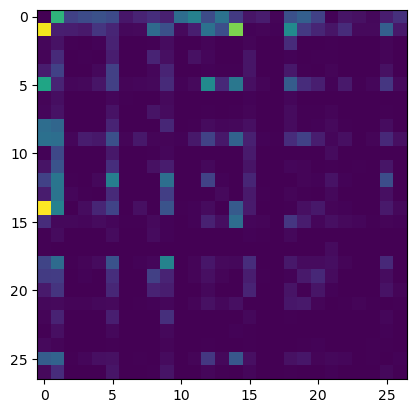

In [82]:
plt.imshow(N)

In [87]:
# Sampling from the Neural Net Model
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    
    while True:
        # Get the prob distribution of next chars for char with index ix
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W # predict log-counts. Also since xenc is some e_i vector, this is just plucking out the row of W for char ix, which is the distribution
        counts = logits.exp()
        p = counts / counts.sum(1, keepdim=True)
        
        # Sample
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

# Shouldn't be different than first approach

cexze.
momasurailezityha.
konimittain.
llayn.
ka.
